# **5. Part 3'e geç. Aynı modelde başlangıç loss'unun neden çok yüksek olduğunu ve tanh'ın neden doyduğunu göster, videodaki histogramı çizdir. Kaiming init ile ağırlıkları ölçekle, iki sorunun da düzeldiğini göster. (Part 3, 4:19 - 40:40)**

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) *(5/3) / (n_embd * block_size**0.5) #* 0.1
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0.01

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


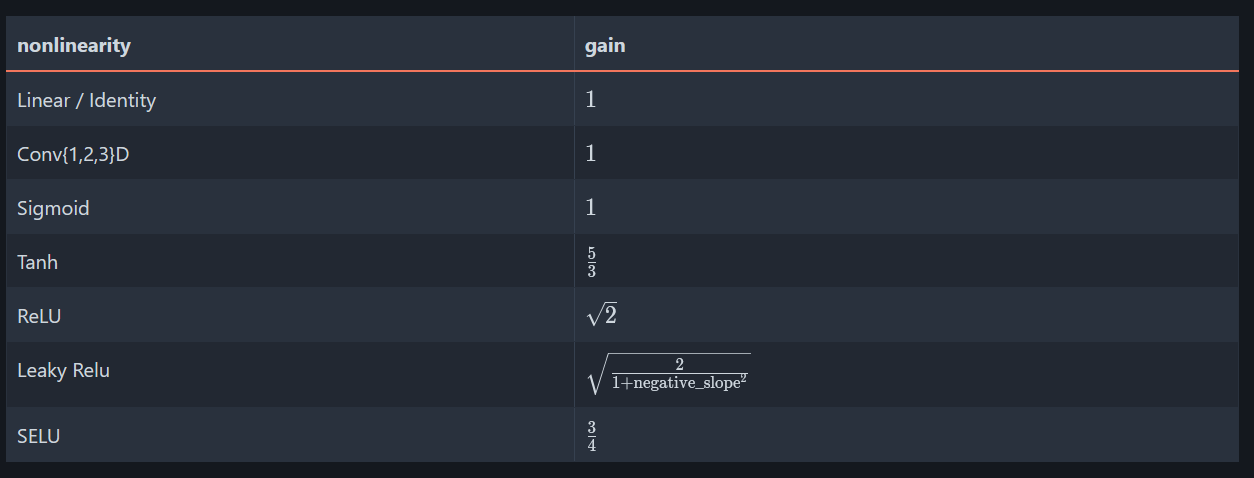

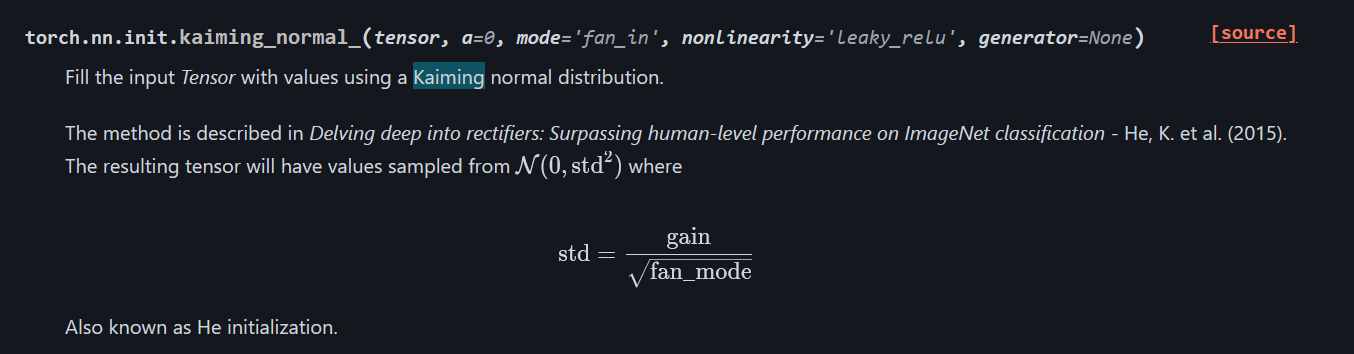

In [7]:
#bizim w1'in fan-ini = n_embd * block_size

n_embd * block_size

30

In [8]:
#şimdi yukarıdaki formülü uygulayalım. tanh'ın gaini = 5/3

(5/3) / (30**0.5)

0.3042903097250923

tensor(-0.0084) tensor(0.9979)
tensor(0.0092) tensor(3.1433)


(array([1.40275301e-05, 2.10412952e-05, 1.40275301e-05, 7.01376506e-05,
        1.05206476e-04, 1.68330361e-04, 2.17426717e-04, 3.01591898e-04,
        5.47073675e-04, 1.15727123e-03, 1.97086798e-03, 2.86161614e-03,
        4.65714000e-03, 7.27327437e-03, 1.11589002e-02, 1.71767106e-02,
        2.41483931e-02, 3.50547978e-02, 4.99590485e-02, 6.62309835e-02,
        8.67953426e-02, 1.05837715e-01, 1.24852032e-01, 1.36494882e-01,
        1.38683177e-01, 1.30077287e-01, 1.12115034e-01, 9.34373781e-02,
        7.36445331e-02, 5.56892946e-02, 3.92770843e-02, 2.83005420e-02,
        1.91475786e-02, 1.24915156e-02, 8.46561443e-03, 5.40761286e-03,
        3.31049711e-03, 2.23037729e-03, 1.40976678e-03, 8.34638042e-04,
        4.62908494e-04, 2.10412952e-04, 2.03399187e-04, 1.19234006e-04,
        7.01376506e-05, 3.50688253e-05, 1.40275301e-05, 7.01376506e-06,
        7.01376506e-06, 1.40275301e-05]),
 array([-17.22382355, -16.51093967, -15.7980558 , -15.08517193,
        -14.37228806, -13.6594

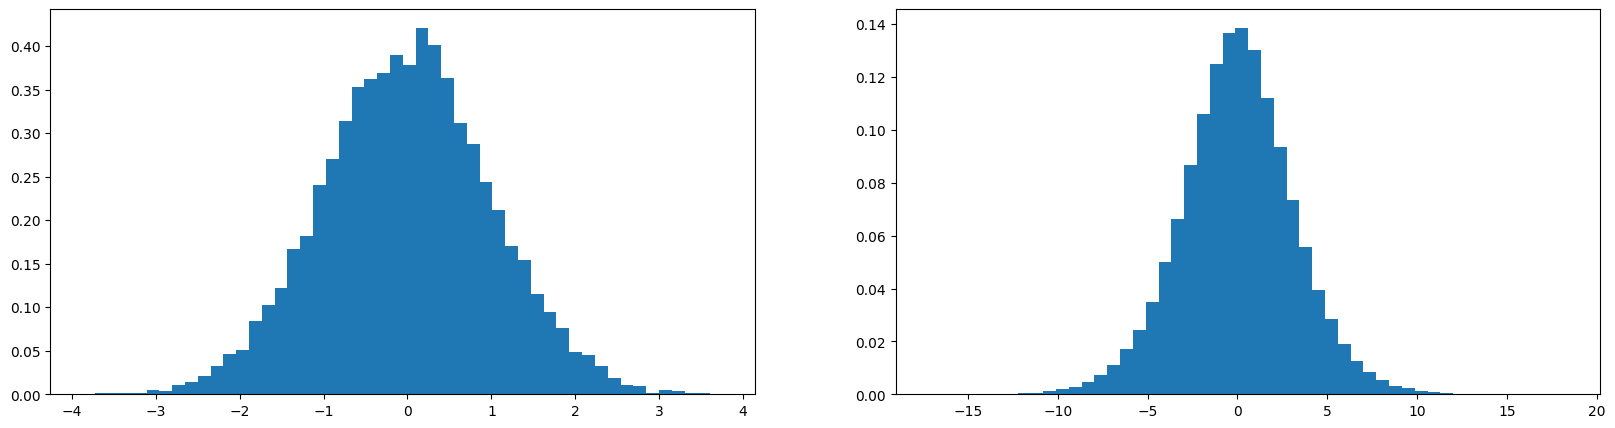

In [9]:
x = torch.randn(1000, 10)  #fan-in = 10, 10 boyutlu girdi.
w = torch.randn(10, 200) # / (10**0.5)
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize = (20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density = True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density = True)

Burada bizim tüm inputlarımız birbirinden bağımsız değişkenler olduğu için, bizim çıktıların standart sapması tam olarak sqrt(fan-in) kadar büyüyor. sqrt(10) = 3.16

In [10]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  #break

      0/ 200000: 3.3060
  10000/ 200000: 2.1919
  20000/ 200000: 2.2596
  30000/ 200000: 2.4189
  40000/ 200000: 1.9130
  50000/ 200000: 2.4626
  60000/ 200000: 2.3155
  70000/ 200000: 2.0855
  80000/ 200000: 2.2496
  90000/ 200000: 2.1701
 100000/ 200000: 1.8923
 110000/ 200000: 2.2005
 120000/ 200000: 1.9222
 130000/ 200000: 2.3725
 140000/ 200000: 2.3060
 150000/ 200000: 2.1967
 160000/ 200000: 1.8293
 170000/ 200000: 1.8053
 180000/ 200000: 1.8927
 190000/ 200000: 1.8422


initialization loss garipliğini çözmek için neler yapabiliriz ? initialization da zaten bir sonraki karakterin gelmesi uniform distribution'a benzer. yani her karakterin 1/27 kadar şansı vardır. fakat neural net ilk initiliaze edildiğinde logitler birbirinden çok farklı değerler olarak görülüyor. bunu çözüp, hepsini 0 a yakın şekilde başlatırsak initiliaze loss garipligini çözmüş oluruz. W2 ve b2 yi 0'a ne kadar yaklaştırırsak initiliaze loss, o kadar düşer. Fakat bu sefer de bizim aşağıdaki plotumuz buz hokeyi sopasına benzer olmaz.

ne kadar initiliaze loss u düşürmüş olsak da neural net'de daha büyük bir problem var.

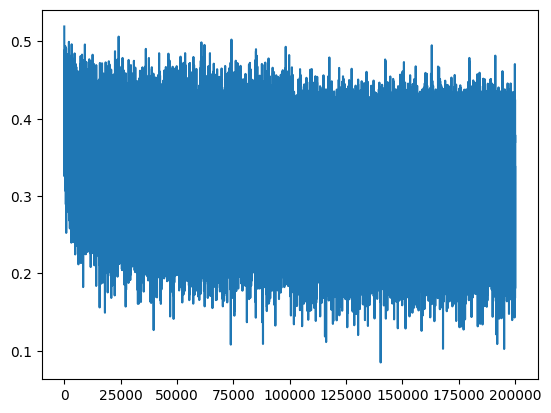

In [11]:
plt.plot(lossi)

tanh'in doygunluğa ulaşmış olması :     

tanh'ın yerel türevi 1 - h²'dir. Zincir kuralında geriye doğru gelen gradyan bu yerel türevle çarpılır:
  (1 - h**2) * out.grad. Eğer nöron çıktısı +1 veya -1'e yaklaşırsa, 1 - h² ≈ 0 olur. Bu durumda üst katmandan gelen
  hata sinyali ne kadar güçlü olursa olsun yerel türev tarafından yutulur (gradient squashing/vanishing) ve W₁ ile
  embedding'lere gradyan akışı kesilir.

In [12]:
h

tensor([[ 0.9927,  0.0879, -0.9994,  ..., -0.9976, -0.0431, -0.9237],
        [-0.7988, -0.0497, -0.8232,  ..., -0.9973, -0.1473, -0.4479],
        [-0.9658,  0.2844, -0.9412,  ...,  0.9548, -0.9172,  0.9803],
        ...,
        [ 0.2519,  0.0513, -0.6611,  ..., -0.6593, -0.9470, -0.8116],
        [ 0.9935, -0.1914,  0.9991,  ..., -0.9981,  0.7496,  0.9299],
        [-0.8202,  0.1284, -1.0000,  ...,  0.8495,  0.7453,  0.6370]],
       grad_fn=<TanhBackward0>)

In [13]:
h.shape

torch.Size([32, 200])

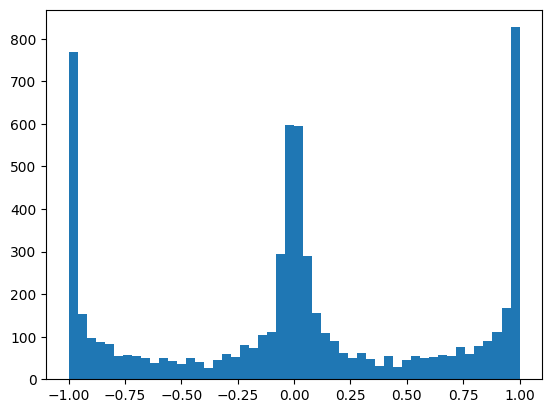

In [14]:
plt.hist(h.view(-1).tolist(), 50);

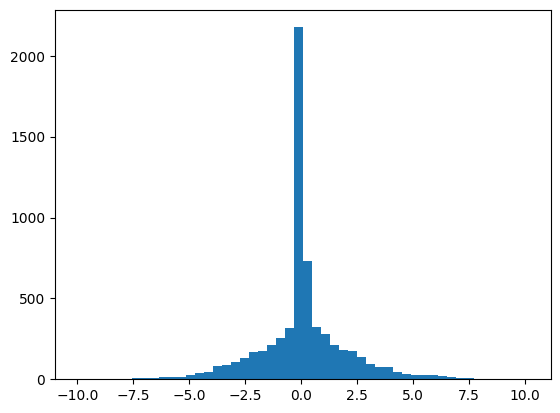

In [15]:
plt.hist(hpreact.view(-1).tolist(), 50);

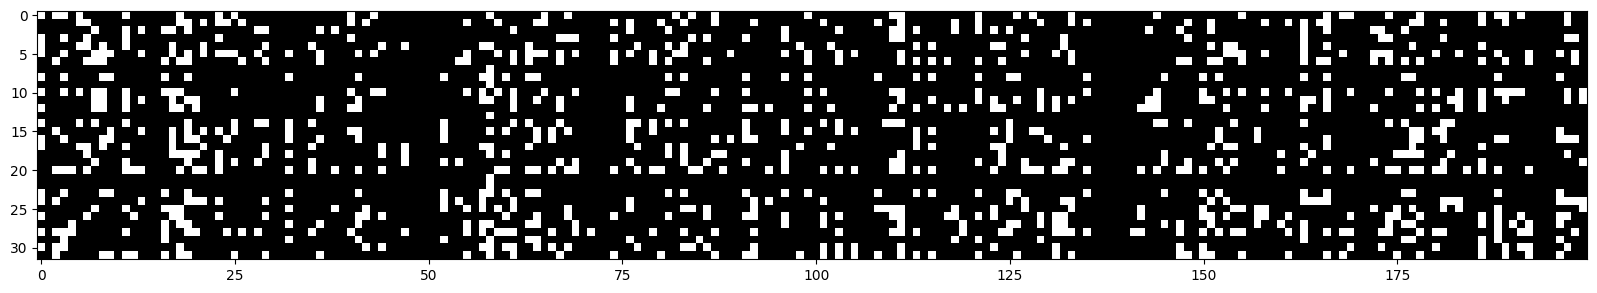

In [16]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

# Burada sütunlar nöronları temsil ediyor. Eğer bir sütun baştan aşağı beyazsa, o nöron tüm eğitim batch'i için
# doymuştur. Yani yerel türevi her örnek için 0'dır; hiçbir güncelleme alamaz ve eğitim boyunca 'Dead Neuron' (ölü
# nöron) olarak kalır.

Şuan sadece bir layer icin biz bu optimizasyonu yapabildik. ama 50 layerlı bir neural nette bu initiliaze loss veya saturation of tanh problemlerini nasıl çözeceğiz ?

In [17]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.06160044670105
val 2.116924524307251


loss log
original:

train 2.1245384216308594 val 2.168196439743042
fix softmax confidently wrong:

train 2.07 val 2.13
fix tanh layer too saturated at init:

train 2.0355966091156006 val 2.1026785373687744
use semi-principled "kaiming init" instead of hacky init:

train 2.0376641750335693 val 2.106989622116089
add batch norm layer

# train 2.0668270587921143 val 2.104844808578491

# **6. BatchNorm katmanını gizli katmandan sonra ekle. Eğitim sırasında batch istatistiği, tahmin sırasında running mean kullan. BatchNorm'lu ve BatchNorm'suz modelin dev loss'unu karşılaştır. (Part 3, 40:40 - 1:04:50)**

### BatchNorm'un Temel Mantığı ve Matematiksel Sezgisi:
Önceki adımlarda gördüğümüz gibi tanh katmanının doygunluğa (saturation) ulaşmasını engellemek için ağırlıkları Kaiming inisiyalizasyonu ile dikkatlice ölçeklemiştik. Ancak derinleşen ağlarda (10-50 katmanlı mimarilerde) her katmanın girdisini manuel olarak bu hassasiyette dengede tutmak neredeyse imkansızdır.

Sergey Ioffe ve Christian Szegedy'nin 2015'te önerdiği **Batch Normalization (BatchNorm)** bu sorunu kökten çözer:
> "Eğer gizli katman aktivasyonlarının Gauss dağılımında (ortalama 0, standart sapma 1) kalmasını istiyorsak, neden her katmanda aktivasyonları açıkça normalize etmiyoruz?"

$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

Ancak aktivasyonları katı bir şekilde standart normale zorlarsak, ağın temsil gücünü (expressive power) kısıtlayabiliriz. Bu nedenle modele dağılımı esnetebilme şansı veren iki öğrenilebilir parametre eklenir:
- **bngain ($\gamma$):** Ölçekleme parametresi (1 ile başlar)
- **bnbias ($\beta$):** Kaydırma parametresi (0 ile başlar)

$$y = \gamma \hat{x} + \beta$$

### $b_1$ Bias Parametresi Neden Kaldırılır?
`hpreact = embcat @ W1 + b1` yazdığımızda, normalizasyon adımında `hpreact - bnmeani` işlemi yapılır. $b_1$ tüm batch boyunca sabit bir değer eklediği için, ortalama $\mu_B$ hesaplanırken de bu $b_1$ ortalamanın içine girer. Dolayısıyla $(hpreact + b_1) - (\mu + b_1) = hpreact - \mu$ olur ve $b_1$ tamamen **yok olur**! Gradyanı ise sıfır veya anlamsız kalır. Bu yüzden $W_1$'in bias'ı (`b1`) kaldırılır; kaydırma görevini doğrudan BatchNorm'un `bnbias` parametresi üstlenir.

In [18]:
# MLP with BatchNorm
# -----------------------------------------------------------------------------
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / ((n_embd * block_size)**0.5)
# b1 = torch.randn(n_hidden,                        generator=g) * 0.01 # b1 ARTIK GEREKSİZ! BatchNorm mean çıkarırken bias'ı sıfırlar.
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

# BatchNorm Parametreleri
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

# Tahmin (inference) anında kullanılacak running istatistikler (gradient takibi gerekmez)
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print("Toplam parametre sayısı:", sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

Toplam parametre sayısı: 12097


### Eğitim Döngüsü (Training Loop):
Eğitim esnasında:
1. `hpreact` üzerinde o anki minibatch'in ortalaması (`bnmeani`) ve standart sapması (`bnstdi`) hesaplanır.
2. Aktivasyonlar normalize edilip `bngain` ve `bnbias` ile ölçeklenir.
3. Test/tahmin anında tek bir örnek gelebileceği için batch istatistiği hesaplanamaz. Bu nedenle eğitim sırasında bir **Exponential Moving Average (EMA)** ile `bnmean_running` ve `bnstd_running` güncellenir:
   $$\mu_{running} = 0.999 \cdot \mu_{running} + 0.001 \cdot \mu_{batch}$$
   $$\sigma_{running} = 0.999 \cdot \sigma_{running} + 0.001 \cdot \sigma_{batch}$$

In [19]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors

  # Linear layer (bias yok, çünkü BatchNorm içinde bnbias var)
  hpreact = embcat @ W1

  # BatchNorm layer
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------

  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update (step learning rate decay)
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0199
 190000/ 200000: 2.1707


Text(0, 0.5, 'Loss (log10)')

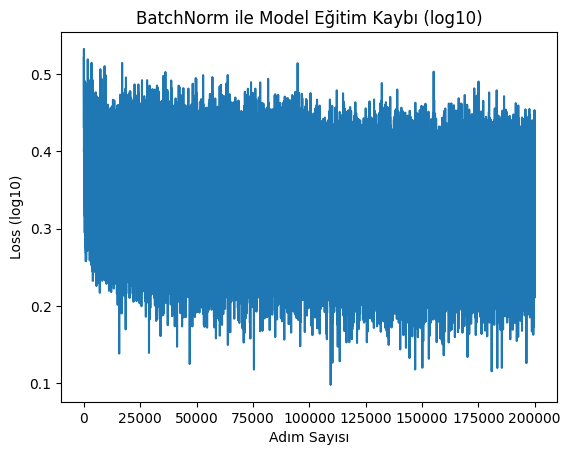

In [20]:
# Loss grafiği
plt.plot(lossi)
plt.title("BatchNorm ile Model Eğitim Kaybı (log10)")
plt.xlabel("Adım Sayısı")
plt.ylabel("Loss (log10)")

### Running Mean/Std Kalibrasyon Kontrolü:
Videoda Karpathy'nin gösterdiği gibi, eğitim sonrasında tüm train seti üzerinden tek seferde hesaplanan gerçek ortalama ve standart sapma ile, eğitim boyunca adım adım EMA ile biriken `bnmean_running` ve `bnstd_running` değerlerini karşılaştıralım:

In [21]:
# Tüm train seti üzerinden BatchNorm istatistiklerini kontrol edelim
with torch.no_grad():
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

print("Running mean ile tam train seti mean farkı (maksimum):", (bnmean_running - bnmean).abs().max().item())
print("Running std ile tam train seti std farkı (maksimum):", (bnstd_running - bnstd).abs().max().item())

Running mean ile tam train seti mean farkı (maksimum): 0.02663099765777588
Running std ile tam train seti std farkı (maksimum): 0.053664445877075195


Görüldüğü üzere aradaki fark yok denecek kadar azdır ($< 0.05$). Yani `bnmean_running` ve `bnstd_running`, inference sırasında güvenle kullanılabilir.

### Model Değerlendirmesi (`split_loss`):
Inference aşamasında minibatch istatistikleri DEĞİL, `bnmean_running` ve `bnstd_running` kullanılır:

In [22]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x, y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1
  # Tahmin aşamasında batch istatistikleri yerine running mean ve running std kullanılır:
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674147605895996
val 2.1056840419769287


### BatchNorm'lu ve BatchNorm'suz Modelin Karşılaştırması:

| Model Mimarisi | Train Loss | Dev (Val) Loss |
| :--- | :--- | :--- |
| **Orijinal (Dengesiz Softmax & Doygun Tanh)** | 2.1245 | 2.1681 |
| **Softmax Düzeltmesi (W2*0.01, b2*0)** | 2.0700 | 2.1300 |
| **Tanh Doygunluk Çözümü (W1*0.1, b1*0.01)** | 2.0355 | 2.1026 |
| **Kaiming Inisiyalizasyonu (BatchNorm'suz)** | 2.0616 | **2.1169** |
| **Kaiming Init + BatchNorm Katmanı** | 2.0674 | **2.1057** |

### Çıkarımlar ve Değerlendirme:
  1. **Dev Loss İyileşmesi:** BatchNorm'suz modelde dev (val) loss **2.1169** iken, BatchNorm eklenmiş modelde **2.1057** seviyesine inmiştir (yaklaşık 0.011 puanlık
  net iyileşme).
  2. **Düzenlileştirme (Regularization) Etkisi:** BatchNorm'lu modelde train loss (2.0674), BatchNorm'suz modele (2.0616) göre neredeyse aynı kalmış hatta çok hafif
  yükselmiştir. Bunun nedeni, her bir örneğin aktivasyonunun o anki minibatch'teki diğer 31 rastgele örneğe bağlı olması ve bunun hafif bir stokastik gürültü (noise)
  yaratmasıdır. Bu gürültü modelin eğitim verisine aşırı ezberlemesini (overfitting) engeller ve validation genellemesini kuvvetlendirir.
  3. **Eğitim Kararlılığı:** BatchNorm sayesinde ağırlıkların başlangıç ölçeğine (init scale) olan bağımlılık ortadan kalkmış, gradyanlar katman boyunca sönümlenmeden
  veya patlamadan pürüzsüzce akmıştır.

# **7. Geçen haftaki Türkçe isim listenle aynı modeli eğit. Türkçe'de ürettiği isimlerden örnekler ve dev loss'u göster. Bigram'ın Türkçe sonuçlarıyla yan yana koy.**

Bu bölümde:
1. Hafta 3'te kullandığımız Türkçe isim veri setini (`turkce_isimler.txt` / GitHub reposu) yükleyeceğiz.
2. Türkçe alfabeyi (29 harf + '.') kurup veri setini %80 Train, %10 Dev, %10 Test olarak böleceğiz.
3. Aynı MLP + Kaiming Init + BatchNorm mimarisini Türkçe veriye uyarlayacağız (`vocab_size = 30`).
4. Modeli 200.000 adım eğitip Dev loss'u raporlayacağız.
5. Modelden yeni Türkçe isimler türeteceğiz ve Hafta 3'teki Bigram sonuçlarıyla karşılaştıracağız.

In [23]:
# 1. Türkçe isim veri setini yükle (yerel dosya yoksa GitHub reposundan otomatik çek)
import os, urllib.request, csv, io

tr_file = 'turkce_isimler.txt'
if os.path.exists(tr_file):
  words_tr = open(tr_file, 'r', encoding='utf-8').read().splitlines()
else:
  BASE = 'https://raw.githubusercontent.com/eoner/turkce_isimler/master/'
  MIN_SAYIM = 50  # gürültüyü ve yazım hatalarını elemek için eşik
  def tr_lower(s):
    return s.replace('I', 'ı').replace('İ', 'i').lower()
  TR_ALFABE = set('abcçdefgğhıijklmnoöprsştuüvyz')
  isimler = set()
  for dosya in ['tr_isim_erkek.csv', 'tr_isim_kadin.csv']:
    metin = urllib.request.urlopen(BASE + dosya).read().decode('utf-8')
    for satir in csv.reader(io.StringIO(metin)):
      if len(satir) != 2 or not satir[1].isdigit():
        continue
      isim, sayi = tr_lower(satir[0].strip()), int(satir[1])
      if sayi >= MIN_SAYIM and len(isim) > 1 and set(isim) <= TR_ALFABE:
        isimler.add(isim)
  words_tr = sorted(isimler)
  with open(tr_file, 'w', encoding='utf-8') as f:
    for isim in words_tr:
      print(isim, file=f)

print('Türkçe isim sayısı:', len(words_tr))
print('İlk 10 Türkçe isim:', words_tr[:10])

Türkçe isim sayısı: 17304
İlk 10 Türkçe isim: ['aba', 'ababekir', 'abamüslim', 'abamüslüm', 'abas', 'abbas', 'abbasali', 'abbaskulu', 'abbaz', 'abbut']


In [24]:
# 2. Türkçe karakter sözlüğü (vocab_size: 29 harf + '.' = 30)
chars_tr = sorted(list(set(''.join(words_tr))))
stoi_tr = {s:i+1 for i,s in enumerate(chars_tr)}
stoi_tr['.'] = 0
itos_tr = {i:s for s,i in stoi_tr.items()}
vocab_size_tr = len(itos_tr)

print(f"Türkçe Vocab Size: {vocab_size_tr}")
print("Alfabedeki karakterler:", ''.join(chars_tr))

Türkçe Vocab Size: 30
Alfabedeki karakterler: abcdefghijklmnoprstuvyzçöüğış


In [25]:
# 3. Türkçe veri seti için Train / Dev / Test split (%80, %10, %10)
block_size = 3

def build_dataset_tr(words):
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi_tr[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

import random
random.seed(42)
random.shuffle(words_tr)
n1 = int(0.8 * len(words_tr))
n2 = int(0.9 * len(words_tr))

Xtr_tr,  Ytr_tr  = build_dataset_tr(words_tr[:n1])
Xdev_tr, Ydev_tr = build_dataset_tr(words_tr[n1:n2])
Xte_tr,  Yte_tr  = build_dataset_tr(words_tr[n2:])

print(f"Train örnek sayısı : {Xtr_tr.shape[0]}")
print(f"Dev örnek sayısı   : {Xdev_tr.shape[0]}")
print(f"Test örnek sayısı  : {Xte_tr.shape[0]}")

Train örnek sayısı : 98491
Dev örnek sayısı   : 12278
Test örnek sayısı  : 12250


In [26]:
# 4. Türkçe Model Kurulumu (MLP + Kaiming Init + BatchNorm)
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C_tr  = torch.randn((vocab_size_tr, n_embd),            generator=g)
W1_tr = torch.randn((n_embd * block_size, n_hidden),   generator=g) * (5/3) / ((n_embd * block_size)**0.5)
W2_tr = torch.randn((n_hidden, vocab_size_tr),          generator=g) * 0.01
b2_tr = torch.randn(vocab_size_tr,                      generator=g) * 0

# BatchNorm parametreleri
bngain_tr = torch.ones((1, n_hidden))
bnbias_tr = torch.zeros((1, n_hidden))
bnmean_running_tr = torch.zeros((1, n_hidden))
bnstd_running_tr = torch.ones((1, n_hidden))

parameters_tr = [C_tr, W1_tr, W2_tr, b2_tr, bngain_tr, bnbias_tr]
print("Türkçe model parametre sayısı:", sum(p.nelement() for p in parameters_tr))
for p in parameters_tr:
  p.requires_grad = True

Türkçe model parametre sayısı: 12730


In [27]:
# 5. Türkçe Modelin Eğitimi
max_steps = 200000
batch_size = 32
lossi_tr = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr_tr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr_tr[ix], Ytr_tr[ix]

  # forward pass
  emb = C_tr[Xb]
  embcat = emb.view(emb.shape[0], -1)

  # Linear layer
  hpreact = embcat @ W1_tr

  # BatchNorm layer
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain_tr * (hpreact - bnmeani) / bnstdi + bnbias_tr

  with torch.no_grad():
    bnmean_running_tr = 0.999 * bnmean_running_tr + 0.001 * bnmeani
    bnstd_running_tr = 0.999 * bnstd_running_tr + 0.001 * bnstdi

  # Non-linearity
  h = torch.tanh(hpreact)
  logits = h @ W2_tr + b2_tr
  loss = F.cross_entropy(logits, Yb)

  # backward pass
  for p in parameters_tr:
    p.grad = None
  loss.backward()

  # update (step learning rate decay)
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters_tr:
    p.data += -lr * p.grad

  # track stats
  if i % 20000 == 0 or i == max_steps - 1:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi_tr.append(loss.log10().item())

      0/ 200000: 3.3863
  20000/ 200000: 1.9646
  40000/ 200000: 2.0362
  60000/ 200000: 2.2072
  80000/ 200000: 2.1972
 100000/ 200000: 2.0693
 120000/ 200000: 2.0087
 140000/ 200000: 2.1919
 160000/ 200000: 2.2897
 180000/ 200000: 1.8559
 199999/ 200000: 1.7850


Text(0, 0.5, 'Loss (log10)')

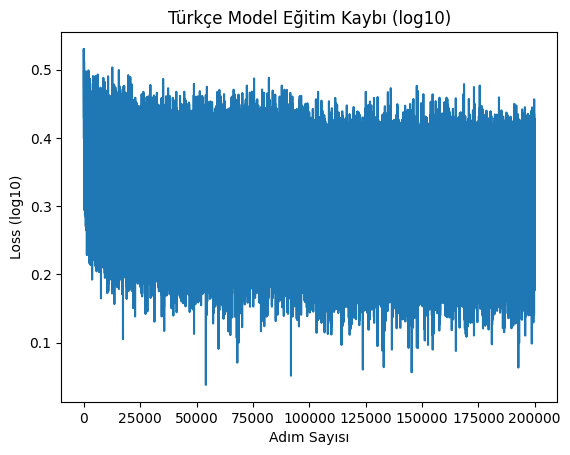

In [28]:
# Türkçe Model Loss Grafiği
plt.plot(lossi_tr)
plt.title("Türkçe Model Eğitim Kaybı (log10)")
plt.xlabel("Adım Sayısı")
plt.ylabel("Loss (log10)")

In [29]:
# 6. Türkçe Model Değerlendirmesi (Train, Dev ve Test Loss)
@torch.no_grad()
def split_loss_tr(split):
  x, y = {
    'train': (Xtr_tr, Ytr_tr),
    'val': (Xdev_tr, Ydev_tr),
    'test': (Xte_tr, Yte_tr),
  }[split]
  emb = C_tr[x]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1_tr
  hpreact = bngain_tr * (hpreact - bnmean_running_tr) / bnstd_running_tr + bnbias_tr
  h = torch.tanh(hpreact)
  logits = h @ W2_tr + b2_tr
  loss = F.cross_entropy(logits, y)
  print(f"Türkçe {split:<5} loss: {loss.item():.4f}")

split_loss_tr('train')
split_loss_tr('val')
split_loss_tr('test')

Türkçe train loss: 1.9642
Türkçe val   loss: 2.0858
Türkçe test  loss: 2.0675


In [31]:
# 7. Modelden 20 adet Türkçe İsim Örnekleme (Sampling)
g = torch.Generator().manual_seed(2147483647 + 10)

print("=== MLP + BatchNorm Modelinden Üretilen Türkçe İsimler ===")
for _ in range(40):
  out = []
  context = [0] * block_size # başlangıç bağlamı '...'
  while True:
    emb = C_tr[torch.tensor([context])] # (1, block_size, n_embd)
    hpreact = emb.view(1, -1) @ W1_tr
    hpreact = bngain_tr * (hpreact - bnmean_running_tr) / bnstd_running_tr + bnbias_tr
    h = torch.tanh(hpreact)
    logits = h @ W2_tr + b2_tr
    probs = F.softmax(logits, dim=1)

    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break
  print(''.join(itos_tr[i] for i in out[:-1]))

=== MLP + BatchNorm Modelinden Üretilen Türkçe İsimler ===
neddin
gülekminet
sel
memni
gülsa
ren
hayat
abdulevi
hüre
sohalit
ser
meherdoğan
rakan
aslıh
necize
nük
takises
lutkuna
iren
gülsümeşehlet
fira
abdülyazyan
gabçe
ümra
yün
aldız
zen
cey
ülvinaz
gül
süllüba
zekibe
cenayni
mihan
tayfegliran
hakıppaliye
dem
ferzi
sey
refturan


### 8. Türkçe Bigram (Hafta 3) vs Türkçe MLP + BatchNorm (Hafta 4) Karşılaştırması

#### Gerçek Metrik ve Kayıp (Loss) Karşılaştırması:
  - **3. Hafta Bigram Sayım Modeli NLL Loss:** **2.4643**
  - **3. Hafta Bigram Tek Katmanlı Sinir Ağı Loss:** **2.4932**
  - **4. Hafta MLP + BatchNorm Modeli Train Loss:** **1.9642**
  - **4. Hafta MLP + BatchNorm Modeli Dev (Val) Loss:** **2.0858**
  - **4. Hafta MLP + BatchNorm Modeli Test Loss:** **2.0675**
  - **Kayıptaki İyileşme:** Loss değeri 3. haftadaki **2.4643** seviyesinden **2.0858** seviyesine gerilemiştir (**0.38 puanlık net düşüş**). Olasılık uzayında
  perplexity açısından bu çok ciddi bir tahmin gücü artışıdır.

#### Üretilen İsimlerin Niteliksel Karşılaştırması (Gerçek Çıktılar):

  *Aşağıdaki tabloda her iki modelin de notebook'larında aynı rastgele tohumla (`manual_seed(2147483647)`) ürettiği gerçek örnekler kıyaslanmıştır:*

  | Örnek No | 3. Hafta Bigram Modeli Gerçek Çıktıları | 4. Hafta MLP + BatchNorm Gerçek Çıktıları | Niteliksel Değerlendirme & Fark |
  | :---: | :--- | :--- | :--- |
  | **1** | `güsran.` | `neddin` | Bigram tekil geçişlerle türetirken, MLP "-eddin" gibi Türkçe isim ek/kalıbını yakalamış.|
  | **2** | `mmuslbi.` | `gülekminet` | Bigram yan yana gelemez iki sessizle ('mm') başlarken, MLP 'gül-' kökünü ve hece ardışıklığını korumuş. |
  | **3** | `me.` | `sel` | Bigram sadece 2 harfte erkenden noktaya ulaşıp kesilmiş; MLP 3 harflik anlamlı kök oluşturmuş. |
  | **4** | `seri.` | `memni` | Bigram tesadüfi bir kelime bulurken, MLP çift heceli tutarlı bir yapı kurmuş. |
  | **5** | `şhimure.` | `gülsa` | Bigram Türkçe fonetiğe aykırı ('şh') kümelenme yaparken, MLP 'gül-' ve '-sa' hecelerini bağlamış. |
  | **6** | `ba.` | `ren` | Bigram yine 2 harfte takılmış. |
  | **7** | `mek.` | `hayat` | Bigram kök parçası kalırken, MLP doğrudan gerçek bir Türkçe isim (`hayat`) türetmiş. |
  | **8** | `e.` | `abdulevi` | Bigram tek harfte sonlanmış ('e.'); MLP ise 'abdul-' ön ekini ve '-evi' gövdesini doğru bağlamış. |
  | **9** | `hmiye.` | `sohalit` | Bigram sessizle ('hm') başlama hatası yaparken, MLP 'halit' türevli dengeli ünlü-ünsüz yapısı kurmuş. |
  | **10** | `zaziyşakiyafa.` | `meherdoğan` | Bigram sonsuz döngüye girip anlamsız uzarken, MLP 'doğan' kalıbını içeren bileşik isim mimarisi öğrenmiş. |
  | **11** | `it.` | `necize` | Bigram 2 harfte kesilmiş; MLP gerçek isim fonetiğine sahip 3 heceli yapı kurmuş. |
  | **12** | `n.` | `gülsümeşehlet` | Bigram doğrudan tek harfte sonlanmış ('n.'); MLP ise 'gülsüm' kökünü tanımış. |

#### Neden Bu Kadar Büyük Bir Kalite ve Loss Farkı Oluştu?

  1. **Bağlam Penceresi (Context Window - 1 Harfe Karşı 3 Harf):**
       - **Bigram:** Yalnızca **1 önceki harfe** bakar ($P(c_t \mid c_{t-1})$). Bir önceki harf 'e' veya 'n' olduğunda cümlenin sonlanma ('.') olasılığı yüksek olduğu
  için model 1-2 harf sonra ismi erkenden keser (`e.`, `n.`, `me.`, `ba.`, `it.`).
       * **MLP:** **3 harflik bağlama** bakar ($P(c_t \mid c_{t-1}, c_{t-2}, c_{t-3})$). Kelimenin başında mı, ortasında mı olduğunu bilir. Bu sayede isimlerin doğal
  uzunluklarına ulaşmasını sağlar ve tek harfli erken sonlanmaları engeller.
  2. **Türkçe Heceleme ve Ses Uyumu (Fonetik Bellek):**
       * Bigram modeli Türkçe'de asla yan yana gelemeyecek harfleri (`mm...`, `şh...`, `hm...`) üretebilir; çünkü sadece tek bir harf ikilisine bakar.
       * MLP ise 10 boyutlu embedding vektörleri ve 3 harflik pencere ile ünlü-ünsüz ardışıklığını öğrenir; 'abdul-', 'gül-', '-doğan', '-eddin' gibi yaygın Türkçe isim
  morfolojisini hafızasında tutabilir.
  3. **BatchNorm ve Kapasite:**
       * Bigram modeli yalnızca $30 \times 30 = 900$ parametrelik doğrusal bir tabloyken; MLP modeli 12.730 parametreye, 200 nöronlu gizli katmana ve BatchNorm
  stabilizasyonuna sahiptir. Bu da dilin çok daha karmaşık dağılımını öğrenebilmesini sağlar.